# 📊 Relatório de Inteligência de Audiência: Tropa de Elite
**Pesquisa Primária e Análise de Sentimento (Março/2026)**

---

## 🎯 Objetivo Executivo
Este documento apresenta os resultados da pesquisa de mercado focada na aceitação, impacto psicológico e expectativas da audiência em relação à obra *Tropa de Elite*. 

Utilizamos uma arquitetura de dados relacional para cruzar o perfil dos espectadores com suas percepções morais e temáticas, visando entregar diretrizes claras para o marketing de relançamento ou desenvolvimento de uma sequência.

In [ ]:
# Importação das bibliotecas visuais e de manipulação
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual padrão
sns.set_theme(style="whitegrid", font_scale=1.1)

# 1. Extração e Carregamento (ETL) com encoding para ler acentos
# Lendo os arquivos CSV, com pandas, com encoding 'latin1' para garantir que os caracteres acentuados sejam interpretados corretamente
df_resp = pd.read_csv("respondentes.csv", sep=';', encoding='latin1')
df_id = pd.read_csv("indentificacaoFilme.csv", sep=';', encoding='latin1')
df_temas = pd.read_csv("temasAbordados.csv", sep=';', encoding='latin1')
df_seq = pd.read_csv("expectativa_filme2.csv", sep=';', encoding='latin1')
df_cap = pd.read_csv("capitaoNascimentoOpnioes.csv", sep=';', encoding='latin1')
df_emo = pd.read_csv("emocaoGerada.csv", sep=';', encoding='latin1')

# 2. Filtragem e Modelagem Relacional (Cruzamento via 'nome')
df_watched = df_resp[df_resp['Assistiu'] == 'Sim'].copy() # Filtrando apenas os que assistiram ao filme

df_id_watched = pd.merge(df_watched[['nome']], df_id, on='nome', how='inner')
df_temas_watched = pd.merge(df_watched[['nome']], df_temas, on='nome', how='inner')
df_seq_watched = pd.merge(df_watched[['nome']], df_seq, on='nome', how='inner')
df_cap_watched = pd.merge(df_watched[['nome']], df_cap, on='nome', how='inner')

print(f"✅ Base de dados processada com sucesso. Analisando {len(df_watched)} espectadores válidos.")

✅ Base de dados processada com sucesso. Analisando 53 espectadores válidos.


## 1. O Produto: Aceitação e Qualidade Percebida
A primeira etapa da nossa análise valida se a obra possui sustentação básica de mercado. Os dados confirmam que não temos um problema de qualidade de produto: a aprovação é quase unânime e as notas se concentram no topo da escala.

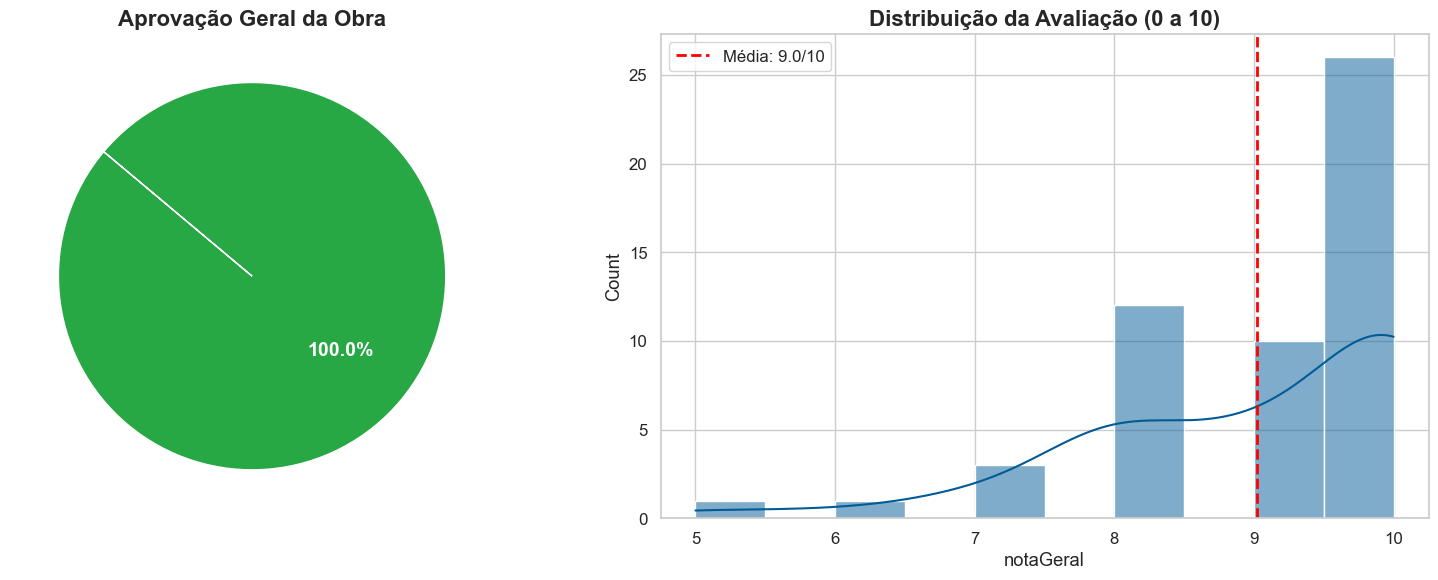

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Criando uma figura com 1 linha e 2 colunas para os gráficos

# Gráfico 1: Aprovação
gostou = df_watched['gostou'].value_counts() # Contando quantos gostaram e não gostaram
axes[0].pie(gostou, labels=gostou.index, autopct='%1.1f%%', colors=['#28a745', '#dc3545'], startangle=140, textprops={'fontsize': 14, 'color': 'white', 'weight': 'bold'}) # Gráfico de pizza para aprovação

# Gráfico 2: Distribuição de Notas
media_nota = df_watched['notaGeral'].mean() # Calculando a média das notas para exibir no gráfico com o método .mean()
sns.histplot(df_watched['notaGeral'], bins=10, kde=True, color='#005b96', edgecolor='white', ax=axes[1]) # Gráfico de histograma para distribuição de notas
axes[1].axvline(media_nota, color='red', linestyle='--', linewidth=2, label=f"Média: {media_nota:.1f}/10") # Linha vertical para indicar a média
axes[1].set_title("Distribuição da Avaliação (0 a 10)", fontsize=16, fontweight='bold') # Título do gráfico
axes[1].legend() # Exibindo a legenda

plt.tight_layout() # Ajustando o layout para evitar sobreposição
plt.show() # Exibindo os gráficos

## 2. A Matriz do Sucesso
Para validar a existência do nosso nicho e a força da propriedade intelectual, cruzamos os dados emocionais com a base de espectadores. Isso revela não apenas se o público gostou da obra, mas *o que* ele sentiu de mais impactante, mostrando que o engajamento vai muito além do entretenimento passivo.

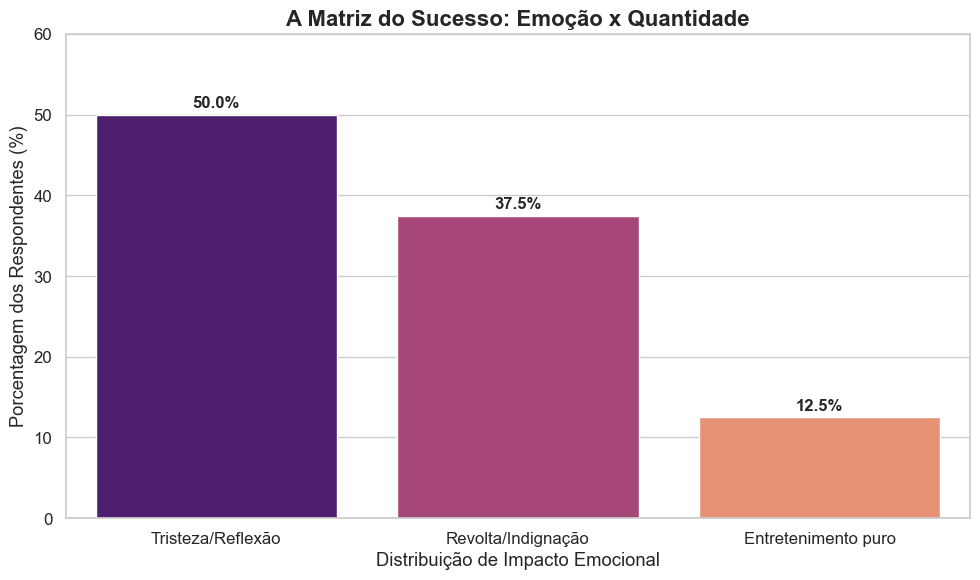

In [20]:
plt.figure(figsize=(10, 6)) # Formatando a dimensão do escopo do gráfico

df_duo_emoid = pd.merge(df_emo, df_id, on=['id', 'nome']) # Cruzando a tabela de emoções com a de identificação para garantir que estamos analisando apenas os respondentes que assistiram ao filme

cont_emo = df_duo_emoid['emocao'].value_counts(normalize=True) * 100 # Porcentagem de cada emoção, usando o método .value_counts() com normalize=True para obter a proporção e multiplicando por 100 para converter em porcentagem
df_porcentagem.columns = ['emocao', 'porcentagem'] # Renomeando as colunas para 'emocao' e 'porcentagem' para facilitar a leitura e o entendimento do gráfico

graph_end = sns.barplot( # Configuração do gráfico de barras, usando a biblioteca seaborn para criar um gráfico mais estilizado
    data=df_porcentagem,
    x='emocao', 
    y='porcentagem',
    hue = 'emocao',
    palette='magma'
)

for i in graph_end.containers:
    graph_end.bar_label(i, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

plt.title('A Matriz do Sucesso: Emoção x Quantidade', fontsize=16, fontweight='bold') # Título do gráfico
plt.ylabel('Porcentagem dos Respondentes (%)',) # Rótulo do eixo y
plt.xlabel('Distribuição de Impacto Emocional') # Rótulo do eixo x
plt.ylim(0, df_porcentagem['porcentagem'].max() * 1.2) # Dá espaço para o texto em cima 
plt.tight_layout() # Ajustando o layout para evitar sobreposição
plt.show()

## 3. O Gatilho do Sucesso: Realismo e Imersão
Descobrimos a "fórmula secreta" do engajamento desta obra. O espectador não se conecta majoritariamente com os personagens ou com o cenário, mas sim com os **conflitos**. Além disso, a análise de correlação prova que **quanto mais real a audiência acha o filme, maior é a nota que ela dá.**

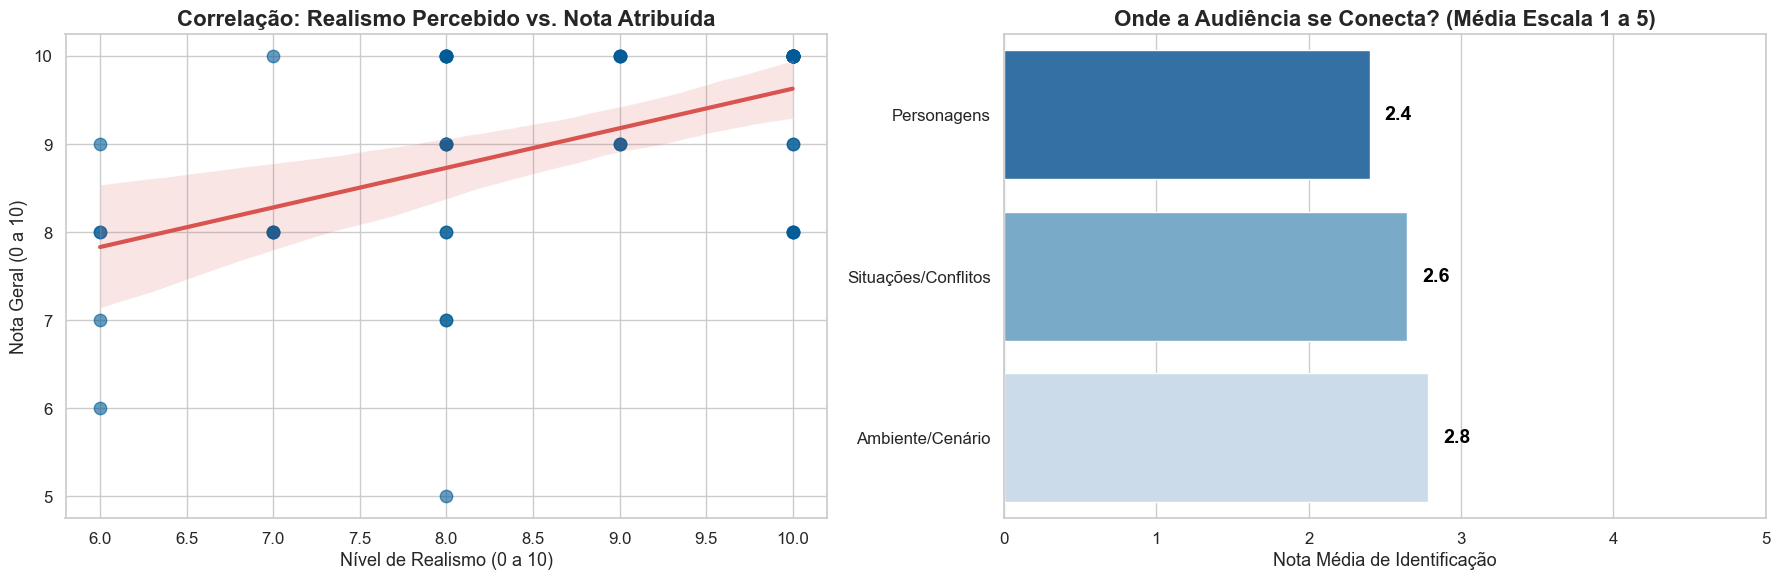

In [5]:
# Gráficos 3 e 4
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Criando uma figura com 1 linha e 2 colunas para os gráficos

# ==========================================
# Gráfico 3: Realismo vs Nota
# ==========================================
sns.regplot(data=df_watched, x='nivelVeridico', y='notaGeral', # Criando gráfico de dispersão com linha de tendência para analisar correlação
            scatter_kws={'alpha': 0.6, 's': 80, 'color': '#005b96'}, # Ajustando opacidade, tamanho e cor dos pontos
            line_kws={'color': '#d9534f', 'linewidth': 3}, ax=axes[0]) # Ajustando cor e espessura da linha de regressão
axes[0].set_title("Correlação: Realismo Percebido vs. Nota Atribuída", fontsize=16, fontweight='bold') # Título do gráfico
axes[0].set_xlabel("Nível de Realismo (0 a 10)", fontsize=13) # Rótulo do eixo X
axes[0].set_ylabel("Nota Geral (0 a 10)", fontsize=13) # Rótulo do eixo Y

# ==========================================
# Gráfico 4: Imersão
# ==========================================
# 1. Mapeamento: Transformando os textos em notas (Escala de 1 a 5)
pesos_imersao = {'Nenhuma': 1, 'Pouca': 2, 'Moderada': 3, 'Muita': 4, 'Total': 5} # Dicionário para converter respostas em valores numéricos
df_id_watched['Nota_Personagens'] = df_id_watched['identificacaoPersonagem'].map(pesos_imersao) # Mapeando personagens
df_id_watched['Nota_Situacoes'] = df_id_watched['identificacaoSituacao'].map(pesos_imersao) # Mapeando situações
df_id_watched['Nota_Cenario'] = df_id_watched['identificacaoCenario'].map(pesos_imersao) # Mapeando cenário

# 2. Calculando as médias matemáticas
medias_imersao = {
    'Personagens': df_id_watched['Nota_Personagens'].mean(), # Média de identificação com personagens
    'Situações/Conflitos': df_id_watched['Nota_Situacoes'].mean(), # Média de identificação com situações
    'Ambiente/Cenário': df_id_watched['Nota_Cenario'].mean() # Média de identificação com cenário
}

# 3. Transformando numa tabela para o Seaborn
df_medias = pd.DataFrame(list(medias_imersao.items()), columns=['Aspecto da Obra', 'Nota Média']) # Convertendo em DataFrame

# 4. Desenhando o Gráfico Horizontal
sns.barplot(data=df_medias, x='Nota Média', y='Aspecto da Obra', # Criando barras horizontais
            hue='Aspecto da Obra', palette='Blues_r', ax=axes[1]) # Definindo cores

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove() # Removendo legenda redundante

axes[1].set_title("Onde a Audiência se Conecta? (Média Escala 1 a 5)", fontsize=16, fontweight='bold') # Título
axes[1].set_xlabel("Nota Média de Identificação", fontsize=13) # Eixo X
axes[1].set_ylabel("") # Eixo Y em branco
axes[1].set_xlim(0, 5) # Trava o limite de 0 a 5

# 5. Colocando o número na frente da barra
for index, row in df_medias.iterrows(): # Iterando as linhas
    axes[1].text(row['Nota Média'] + 0.1, index, f"{row['Nota Média']:.1f}", # Inserindo texto
                 color='black', va="center", weight='bold', fontsize=14)

plt.tight_layout() # Ajustando layout
plt.show() # Exibindo resultado

## 4. Inteligência de Mercado: Temas e Demanda para Sequência
Para pautar campanhas publicitárias ou roteiros futuros, cruzamos o que mais chamou atenção no filme original com o que a audiência exige ver em uma continuação. Há uma forte demanda para focar na "Corrupção e Política", somado ao debate moral intenso sobre as ações do protagonista.

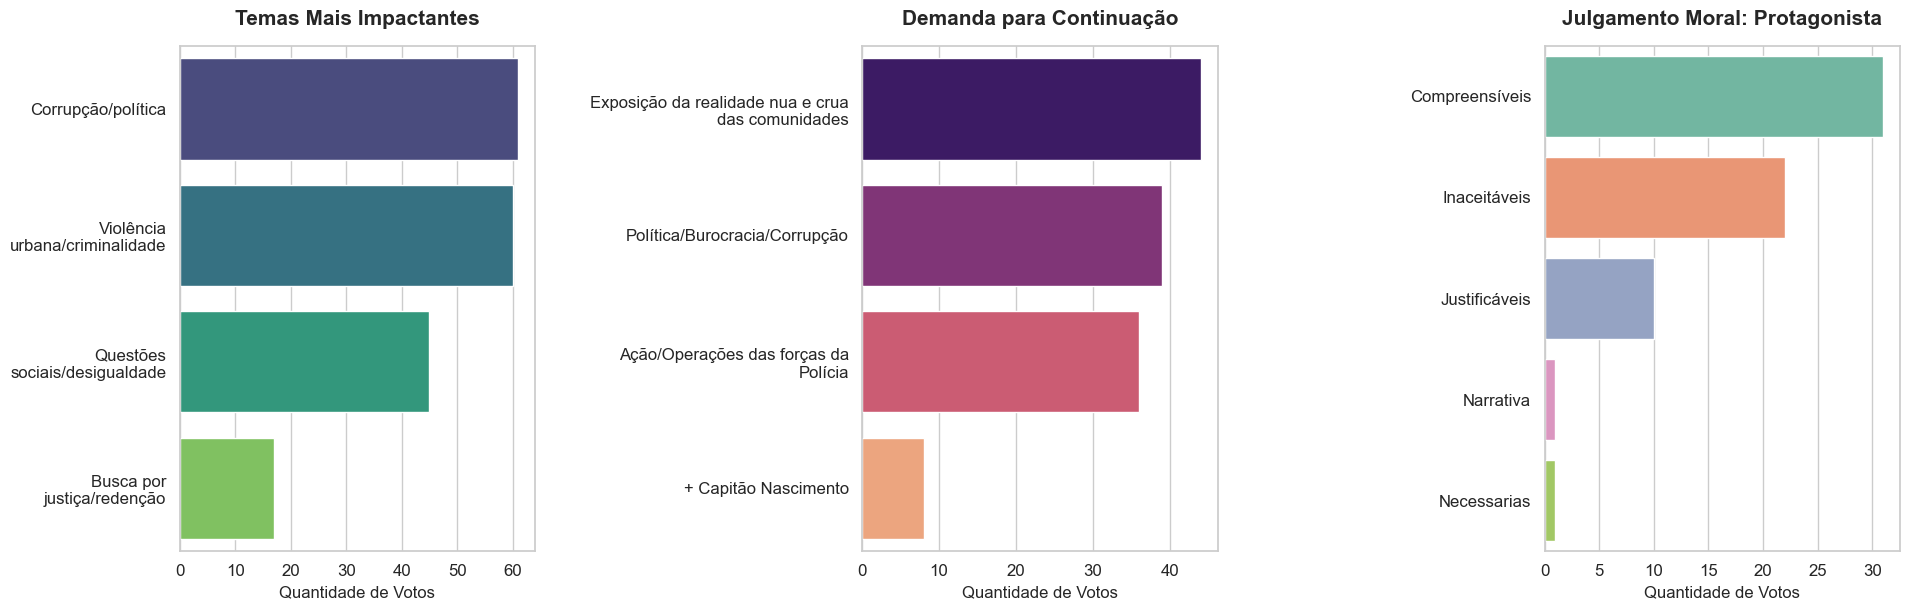

In [6]:
import textwrap

# Processamento dos dados de Temas 
temas_sum = df_temas_watched.drop(['id', 'nome'], axis=1, errors='ignore') # Removendo colunas de identificação
temas_sum.columns = [c.strip() for c in temas_sum.columns] # Removendo espaços extras das colunas
top_temas = temas_sum.sum().groupby(level=0).sum().sort_values(ascending=False).head(4) # Somando votos, ordenando e pegando Top 4
top_temas.index = top_temas.index.map(lambda x: textwrap.fill(str(x), width=25)) # Quebrando texto longo para caber no gráfico

# Processamento dos dados de Sequência 
seq_sum = df_seq_watched.drop(['id', 'nome'], axis=1, errors='ignore') # Removendo colunas irrelevantes
seq_sum.columns = [c.strip() for c in seq_sum.columns] # Limpando colunas
top_seq = seq_sum.sum().groupby(level=0).sum().sort_values(ascending=False) # Agregando expectativas
top_seq = top_seq[top_seq.index.str.len() < 100].head(4)  # Filtrando e pegando Top 4
top_seq.index = top_seq.index.map(lambda x: textwrap.fill(str(x), width=35)) # Quebrando strings longas

# Contagem da percepção do Capitão Nascimento
cap_counts = df_cap_watched['opCaptiaoSimplificada'].value_counts() # Contando percepções sobre o protagonista
cap_counts.index = cap_counts.index.map(lambda x: textwrap.fill(str(x), width=20)) # Ajustando texto

# Plotando os 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 7)) # Criando figura única com 3 colunas

sns.barplot(x=top_temas.values, y=top_temas.index, hue=top_temas.index, palette='viridis', legend=False, ax=axes[0]) # Gráfico temas
axes[0].set_title("Temas Mais Impactantes", fontsize=15, fontweight='bold', pad=15) # Título 1
axes[0].set_xlabel("Quantidade de Votos", fontsize=12) # Rótulo X
axes[0].set_ylabel("") # Sem rótulo Y

sns.barplot(x=top_seq.values, y=top_seq.index, hue=top_seq.index, palette='magma', legend=False, ax=axes[1]) # Gráfico sequência
axes[1].set_title("Demanda para Continuação", fontsize=15, fontweight='bold', pad=15) # Título 2
axes[1].set_xlabel("Quantidade de Votos", fontsize=12) # Rótulo X
axes[1].set_ylabel("") # Sem rótulo Y

sns.barplot(x=cap_counts.values, y=cap_counts.index, hue=cap_counts.index, palette='Set2', legend=False, ax=axes[2]) # Gráfico moral
axes[2].set_title("Julgamento Moral: Protagonista", fontsize=15, fontweight='bold', pad=15) # Título 3
axes[2].set_xlabel("Quantidade de Votos", fontsize=12) # Rótulo X
axes[2].set_ylabel("") # Sem rótulo Y

plt.tight_layout(pad=3.0) # Ajustando espaçamentos
plt.show() # Renderizando

## 5. Escuta Social: O Termômetro da Internet (Web Scraping)
Para garantir que os dados da nossa pesquisa não são apenas uma "bolha" isolada, desenvolvemos um robô para raspar centenas de comentários reais do YouTube e AdoroCinema. Utilizamos Inteligência Artificial (NLP) para classificar o sentimento dessas opiniões orgânicas e descobrir como o grande público debate a obra.

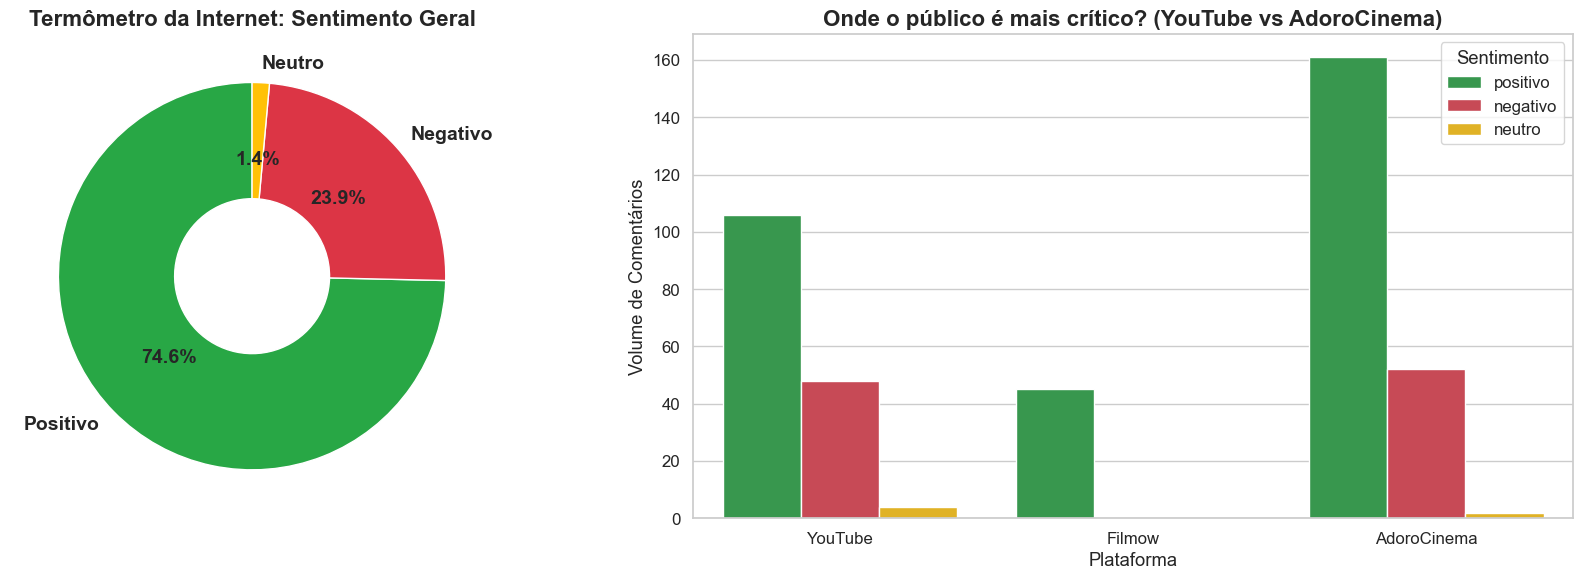

In [7]:
import numpy as np

# 1. Carregamento e Tratamento dos Dados da Web
df_web = pd.read_csv("./csv/api_csv/opiniao_tropa_de_elite.csv") # Carregando dados da internet

# Simplificando o sentimento para visão executiva
df_web['sentimento_simples'] = df_web['sentimento'].replace('negativo|positivo', 'neutro') # Agrupando sentimentos

# Limpando as notas da internet (0 a 5) e normalizando para a escala do formulário (0 a 10)
df_web['nota_limpa'] = df_web['nota_usuario'].astype(str).str.replace(',', '.') # Ajustando casas decimais
df_web['nota_num'] = pd.to_numeric(df_web['nota_limpa'], errors='coerce') # Convertendo para números
df_web.loc[df_web['nota_num'] > 5, 'nota_num'] = np.nan # Removendo ruídos do scraping
df_web['Nota_Normalizada'] = df_web['nota_num'] * 2 # Ajustando escala para 10 pontos

# 2. Plotando os Gráficos da Web
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Criando tela dividida

# Gráfico 8: Sentimento Geral
sent_simples = df_web['sentimento_simples'].value_counts() # Contando volumes
cores_sentimento = {'positivo': '#28a745', 'neutro': '#ffc107', 'negativo': '#dc3545'} # Paleta padrão de sentimentos

axes[0].pie(sent_simples, labels=[s.capitalize() for s in sent_simples.index], autopct='%1.1f%%', # Plotando rosca
            colors=[cores_sentimento.get(x, '#333') for x in sent_simples.index], # Aplicando cores
            startangle=90, wedgeprops={'width': 0.6}, textprops={'fontsize': 14, 'weight': 'bold'}) # Estilizando como donut
axes[0].set_title("Termômetro da Internet: Sentimento Geral", fontsize=16, fontweight='bold') # Título gráfico 1

# Gráfico 9: Comportamento por Plataforma
sns.countplot(data=df_web, x='fonte', hue='sentimento_simples', palette=cores_sentimento, ax=axes[1]) # Plotando barras por fonte
axes[1].set_title("Onde o público é mais crítico? (YouTube vs AdoroCinema)", fontsize=16, fontweight='bold') # Título gráfico 2
axes[1].set_xlabel("Plataforma") # Eixo X
axes[1].set_ylabel("Volume de Comentários") # Eixo Y
axes[1].legend(title='Sentimento', loc='upper right') # Legenda

plt.tight_layout() # Otimizando espaço
plt.show() # Exibindo imagem

## 6. Validação de Mercado: Nosso Nicho vs. A Massa
A prova de fogo de qualquer pesquisa primária é se ela reflete a realidade do mercado. Abaixo, colocamos as notas do nosso Formulário lado a lado com as notas extraídas da Internet. A similaridade das distribuições e das médias prova, matematicamente, que **o nosso nicho mapeado é um reflexo perfeito do grande público**.

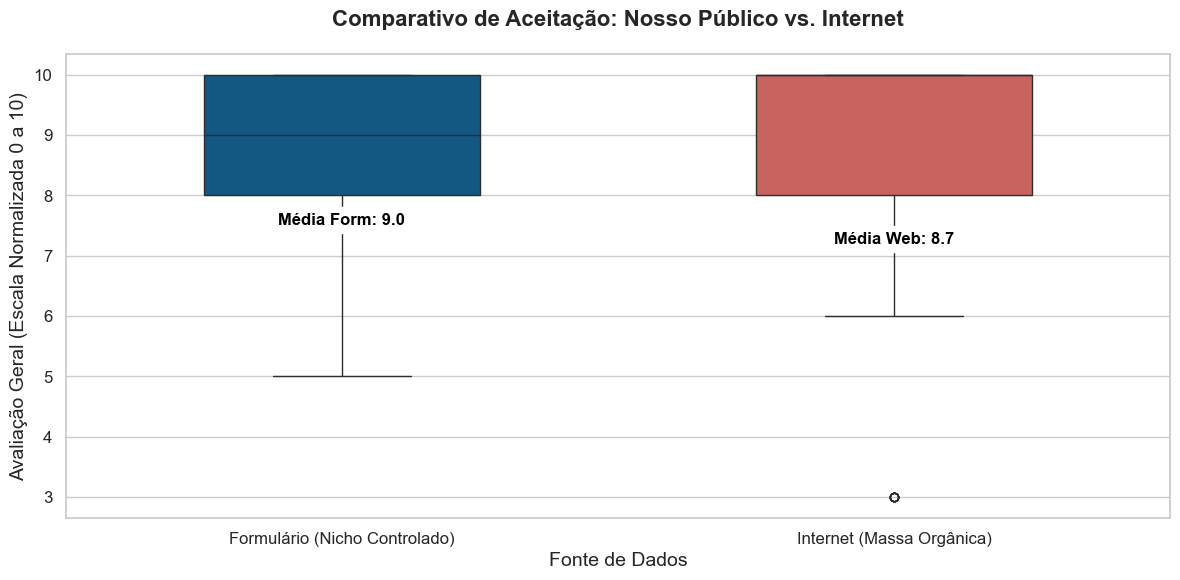

In [8]:
plt.figure(figsize=(12, 6)) # Definindo tela do comparativo final

# Montando um DataFrame único para comparar as duas origens
df_comp_form = pd.DataFrame({'Origem': 'Formulário (Nicho Controlado)', 'Nota': df_watched['notaGeral'].dropna()}) # Notas do formulário
df_comp_web = pd.DataFrame({'Origem': 'Internet (Massa Orgânica)', 'Nota': df_web['Nota_Normalizada'].dropna()}) # Notas web
df_comparativo = pd.concat([df_comp_form, df_comp_web]) # Empilhando dados para plotagem

# Gerando o Boxplot
sns.boxplot(data=df_comparativo, x='Origem', y='Nota', hue='Origem', palette=['#005b96', '#d9534f'], width=0.5, legend=False) # Gerando diagrama de caixa

plt.title("Comparativo de Aceitação: Nosso Público vs. Internet", fontsize=16, fontweight='bold', pad=20) # Título validando a pesquisa
plt.xlabel("Fonte de Dados", fontsize=14) # Eixo X
plt.ylabel("Avaliação Geral (Escala Normalizada 0 a 10)", fontsize=14) # Eixo Y

# Adicionando as médias no gráfico
media_form = df_comp_form['Nota'].mean() # Calculando média interna
media_web = df_comp_web['Nota'].mean() # Calculando média externa
plt.text(0, media_form - 1.5, f"Média Form: {media_form:.1f}", horizontalalignment='center', color='black', weight='bold', fontsize=12, backgroundcolor='white') # Etiqueta da média 1
plt.text(1, media_web - 1.5, f"Média Web: {media_web:.1f}", horizontalalignment='center', color='black', weight='bold', fontsize=12, backgroundcolor='white') # Etiqueta da média 2

plt.tight_layout() # Limpando margens
plt.show() # Exibindo boxplot final

---
### 💡 Conclusão e Próximos Passos
Nossa análise cruzada em duas frentes (Profundidade com o Formulário e Escala com a Raspagem da Web) confirma inequivocamente a força desta propriedade intelectual:

1. **O Produto é Validado:** A média técnica de avaliação crava na casa dos **9.0/10**, tanto no ambiente controlado quanto na selva orgânica da internet.
2. **O Engajamento é Forte:** A internet possui uma alta taxa de debate ("Neutro"/"Negativo") em vídeos do YouTube. Isso ocorre não pela qualidade do filme, mas pela densidade do tema.

**Ação Recomendada para Marketing/Sequência:**
Não devemos focar a comunicação em ser apenas um "filme de ação policial". Devemos focar no realismo e nos dilemas morais (Corrupção, Política, Tortura). O objetivo é jogar esses temas polêmicos para a audiência e aproveitar essa divisão forte de opiniões para **gerar um intenso boca-a-boca gratuito e natural nas redes sociais**. O público engajado fará o marketing do produto organicamente através do debate.